# Learning Latent Representations of Music using Contrastive Learning
by Bjarni, Fabio and Navin

Learning Latent Representations of Music

The model uses a CNN-RNN architecture with triplet loss and autoregressive reconstruction to learn meaningful representations of music by analyzing:
- Audio spectrograms: Visual representations of frequency content over time 📊
- Chromagrams: Representations of pitch class content 🎹
- Tempograms: Representations of rhythmic and tempo information 🥁

The model learns to embed songs in a latent space that captures both acoustic similarities and metadata relationships.


In [75]:
import torch
import torch.nn.functional as F

input_shape = (1024, 2048, 3)  # corresponds to roughly 30 seconds of audio
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [76]:
from model import Song2Vec

model = Song2Vec().to(DEVICE)
state_dict = torch.load("step_1120.pt", map_location=DEVICE, weights_only=True)["model_state_dict"]
wo_orig_mod = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
model.load_state_dict(wo_orig_mod)

model = model.eval()

print(model)

Song2Vec(
  (encoder): CNNEncoder(
    (conv1): Conv2d(3, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(32, 64, kernel_size=(3, 4), stride=(1, 2), padding=(1, 1))
    (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (convlast): Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1))
  )
  (gru_encoder): GRU(256, 512, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (enc_mapping): Linear(in_features=1024, out_features=256, bias=True)
  (gru_decoder): GRU(1, 512, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dec_mapping): Linear(in_features=1024, out_features=256, bias=True)
  (decoder): CNNDecoder(
    (conv1): ConvTranspose2d(1

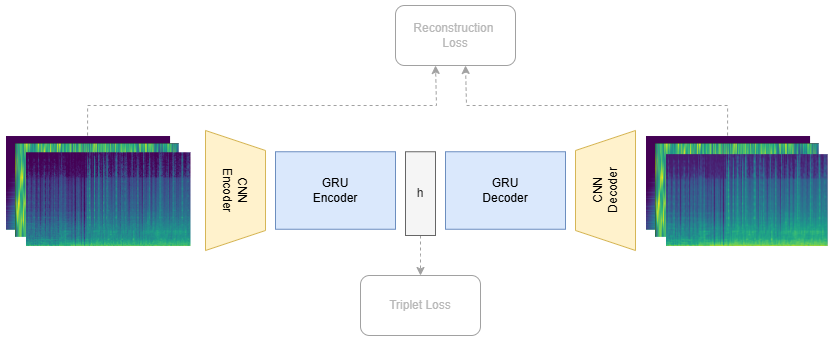

# Model Architecture

The model uses a hybrid CNN-RNN architecture:

Input Processing:
- 3-channel input (spectrograms, chromagrams, tempograms)
- CNNs extract hierarchical features

Sequence Processing:
- CNN features fed into bidirectional GRU
- Processes temporal dependencies
- <b>The final GRU encoder hidden states is mapped to a lower dimension and used as the *embedding*</b>

Decoding:
- Transposed convolutions reconstruct dimensions
- Mirrors encoder with skip connections


# Training objectives

## Triplet Loss

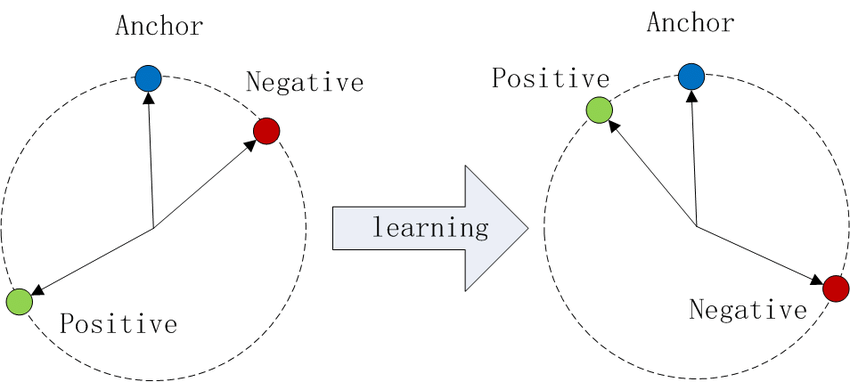

The triplet loss function is used to learn meaningful embeddings in the latent space. The goal is to ensure that:

- Similar items (anchor and positive) are mapped close together in the embedding space
- Different items (anchor and negative) are mapped far apart
- The distance between similar pairs should be less than the distance between different pairs by some margin α

Mathematically, for an anchor point $a$, positive example $p$, and negative example $n$, we want:

$\|f(a)-f(p)\|^2 + \alpha < \|f(a)-f(n)\|^2$

The loss function is defined as: 

$L_{triplet} = \sum[\max(0, \|f(a_i)-f(p_i)\|^2 - \|f(a_i)-f(n_i)\|^2 + \alpha)]$

This pushes similar songs closer together while pulling different songs apart in the latent space.

## Reconstruction Loss

The reconstruction loss is computed as the Mean Squared Error (MSE) between the input x and its reconstruction $\hat{x}$:

$L_{recon} = \|x - \hat{x}\|^2$

## Total loss
Is then the sum of both the triplet and reconstruction losses:

$L_{total} = L_{triplet} + L_{recon}$

# Embedding collapse

Training deep metric learning models like ours faces several challenges:

A key challenge is "embedding collapse" where all embeddings converge to a single point in the latent space. This happens because the model finds a trivial solution that minimizes the triplet loss by mapping everything to the same location, rather than learning meaningful audio features.


<b>Hard Mining</b>: Initially we tried hard negative mining - selecting the most difficult negative examples that are closest to the anchor. However, this led to unstable training and inefficient use of computational resources.

<b>Gradient Stopping</b>: Another approach was to stop gradients selectively during training to prevent the model from finding trivial solutions. This provided some improvement but wasn't sufficient.

<b>Our Solution (Autoencoding)</b>: We ultimately found that adding an autoencoding objective was most effective. By forcing the embeddings to also reconstruct the input audio, we ensure they capture meaningful musical features rather than collapsing to trivial solutions. The reconstruction loss acts as a regularizer on the embedding space.

This hybrid approach of combining metric learning with autoencoding proved to be robust and effective for our music similarity task.


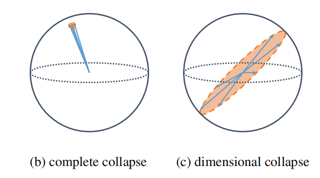

# Vector Database
Vector databases (VDBs) are specialized databases optimized for storing and searching high-dimensional vectors. After generating embeddings from our model on a subset of the FMA dataset, we store these vectors in a VDB for efficient similarity search.

When querying our database, we use cosine similarity to find the most similar songs. For two vectors $a$ and $b$, cosine similarity is defined as:

### $\text{similarity} = \frac{a \cdot b}{\|a\| \|b\|}$

This metric is particularly effective for comparing embeddings since it measures the angle between vectors, making it invariant to vector magnitudes. Values closer to 1 indicate higher similarity.

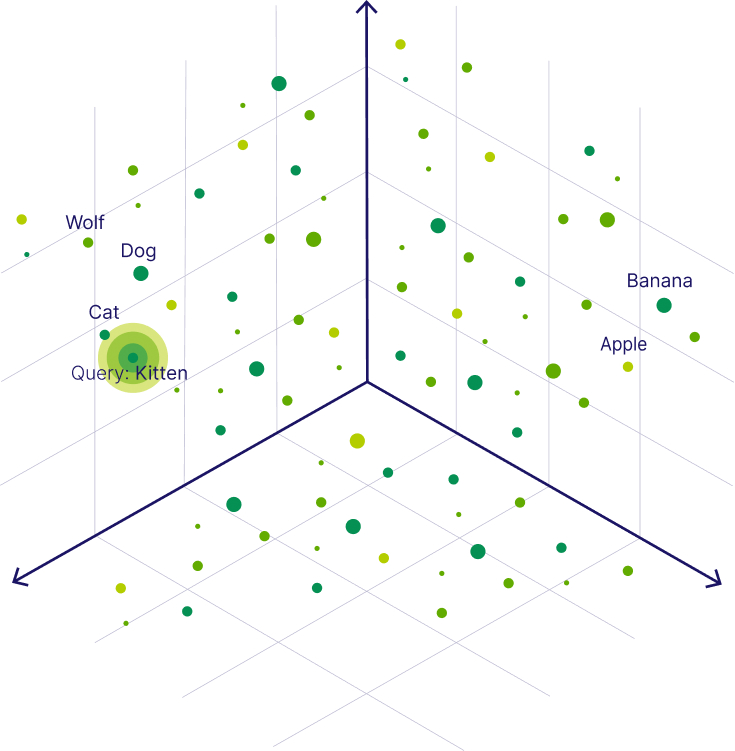

In [113]:
import glob
from os.path import join as pjoin
from pathlib import Path

import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset

from preprocess import process_audio_file

fma_small_files = glob.glob("data/fma_small/**/*.mp3")[:1000]

corrupted_files = [133297, 99134, 108925]

fma_small_files = [file for file in fma_small_files if int(Path(file).stem) not in corrupted_files]

METADATA_FOLDER = "fma_metadata"

GENRE_TO_IDX = {
    'Hip-Hop': 0,
    'Pop': 1,
    'Folk': 2,
    'Experimental': 3,
    'Rock': 4,
    'International': 5,
    'Electronic': 6,
    'Instrumental': 7
}

class AudioDataset(Dataset):
    def __init__(self, file_paths, metadata_folder='fma_metadata'):
        self.file_paths = file_paths
        self.small = pd.read_csv(pjoin(metadata_folder, 'small.csv'))

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        track_id = int(file_path.split('/')[-1].split('.')[0])
        track = self.small[self.small['track_id'] == track_id]
        genre = track['genre'].values[0]

        audio_array = process_audio_file(self.file_paths[idx])
        audio_array = np.ascontiguousarray(audio_array)

        return torch.from_numpy(audio_array).float(), GENRE_TO_IDX[genre]

In [36]:
def collate_fn(batch):
    audio_arrays, genres = zip(*batch)
    return torch.stack(audio_arrays), list(genres)

# Create dataset and dataloader
dataset = AudioDataset(fma_small_files)
batch_size = 16  # Adjust based on your GPU memory
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

# Calculate mean and variance of audio arrays
embeddings = []
genres = []
model.eval()
with torch.no_grad():
    for batch in tqdm(dataloader, desc="Processing audio files"):
        songs, labels = batch
        songs = songs.to(DEVICE)
        batch_embeddings, _, _ = model.encode(songs)
        embeddings.append(batch_embeddings.cpu().numpy())
        genres.append(labels)

embeddings = np.vstack(embeddings)
genres = np.concatenate(genres)

Processing audio files: 100%|██████████| 63/63 [05:32<00:00,  5.27s/it]


# Use Case: Music Retrieval

Our model enables content-based music retrieval and recommendation by learning meaningful audio embeddings. Given a query song, we can find similar songs by:

1. Computing the embedding of the query song
2. Finding nearest neighbors in the embedding space by using cosine similarity
3. Retrieving the most similar / dissimilar songs

This approach has several advantages:
- Works directly from raw audio without requiring tags/metadata
- Can find similar songs across different genres and styles
- Captures both high-level musical concepts and low-level audio features
- Enables fast similarity search through efficient embedding lookups

### First, to show that the embeddings are meaningful, we can visualize them using t-SNE

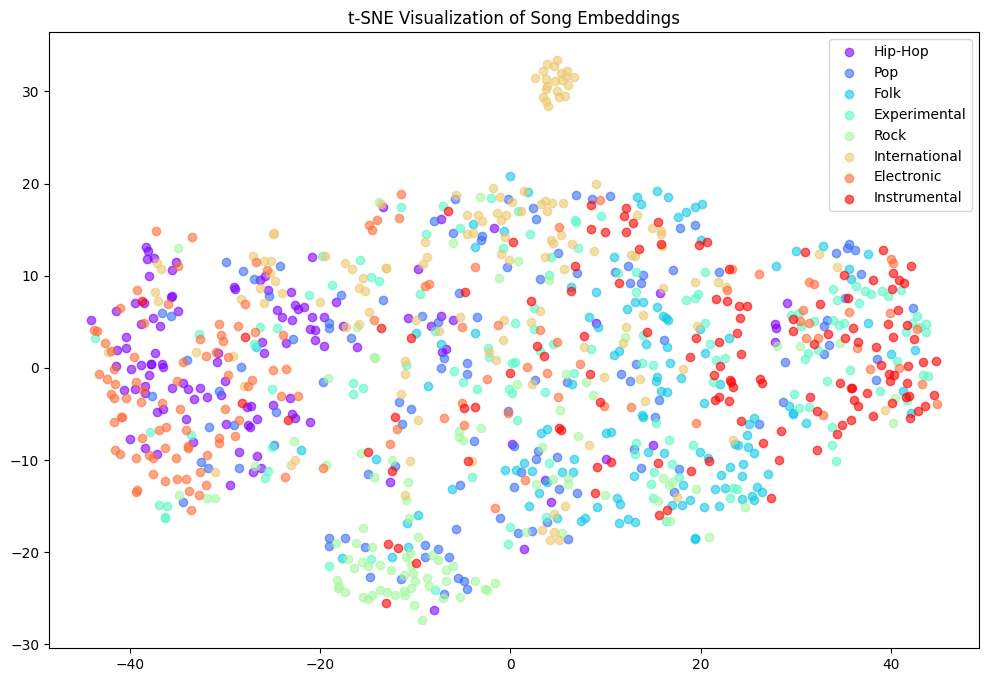

In [46]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Fit TSNE to embeddings
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

# Create scatter plot
plt.figure(figsize=(12, 8))

# Get unique genres and assign colors
unique_genres = np.unique(genres)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_genres)))

# Plot each genre with different color
for genre, color in zip(unique_genres, colors):
    mask = genres == genre
    genre_name = list(GENRE_TO_IDX.keys())[list(GENRE_TO_IDX.values()).index(genre)]
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
               c=[color], label=genre_name, alpha=0.6)

plt.title('t-SNE Visualization of Song Embeddings')
plt.legend()
plt.show()


The distances between clusters in t-SNE visualizations cannot be meaningfully interpreted, as t-SNE distorts global structure to optimize local relationships. Two clusters being far apart doesn't necessarily mean those genres are more dissimilar. This can be seen in the 'international' genre, which lies far apart from the other genres.


The genres overlap but intra-cluster distances are small, indicating that the model has learned to group similar songs together. Additionally, the genres that do overlap have some similarity to each other (e.g. electronic and hip-hop)



In [ ]:
import ipywidgets as widgets
from IPython.display import display, Audio
import librosa
from sklearn.metrics.pairwise import cosine_similarity


def play_audio(file_path):
    y, sr = librosa.load(file_path, duration=30)  # Load up to 30 seconds
    return Audio(data=y, rate=sr)

def create_audio_player(file_path, title):
    audio = play_audio(file_path)
    return widgets.VBox([
        widgets.HTML(f"<b>{title}</b>"),
        widgets.HTML(audio._repr_html_())
    ])

## Querying the VDB

In [114]:
query_file = fma_small_files[-1]  # 30 600

play_audio(query_file)

In [111]:
# Process a single song as the query (using the first song in the list)
query_audio = process_audio_file(query_file)
query_audio = np.ascontiguousarray(query_audio)  # Ensure contiguous memory layout
query_tensor = torch.from_numpy(query_audio).float().unsqueeze(0).to(DEVICE)
with torch.no_grad():
    query_embedding, _, _ = model.encode(query_tensor)


# Calculate cosine similarities
similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 5 most similar and least similar songs
top_5_indices = np.argsort(similarities)[-6:-1][::-1]
bottom_5_indices = np.argsort(similarities)[:5]
top_5_similarities = similarities[top_5_indices]
bottom_5_similarities = similarities[bottom_5_indices]

In [115]:
# Create audio players for query song and top 5 similar songs
query_player = create_audio_player(query_file, "Query Song")

top_5_players = [
    create_audio_player(fma_small_files[index], f"Top {i+1} Similar (Similarity: {similarity:.4f})")
    for i, (index, similarity) in enumerate(zip(top_5_indices, top_5_similarities))
]

# Create audio players for bottom 5 similar songs
bottom_5_players = [
    create_audio_player(fma_small_files[index], f"Bottom {i+1} Similar (Similarity: {similarity:.4f})")
    for i, (index, similarity) in enumerate(zip(bottom_5_indices, bottom_5_similarities))
]

# Display all players
display(widgets.VBox([
    query_player,
    widgets.HBox([
        widgets.VBox([widgets.HTML("<b>Top 5 Most Similar</b>")] + top_5_players),
        widgets.VBox([widgets.HTML("<b>Bottom 5 Least Similar</b>")] + bottom_5_players)
    ])
]))


# Analyzing information content in the embeddings

Our model was trained to autoregressively compress the audio *and* to include information about the metadata in the latent space. The metadata we trained on is "genre", "year of release" and "popularity".

We can analyze the information content in the embeddings by training a genre classifier on them.

In [116]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(embeddings, genres, test_size=0.2, random_state=42)

# Initialize and train Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions on test set
y_pred = rf_classifier.predict(X_test)

# Print classification report
print("Random Forest Classification Report:")
# Get unique labels actually present in the test set
unique_labels = np.unique(y_test)
genre_names = [list(GENRE_TO_IDX.keys())[list(GENRE_TO_IDX.values()).index(genre)] for genre in unique_labels]

print(rf_classifier.score(X_test, y_test))
print(classification_report(y_test, y_pred, target_names=genre_names, labels=unique_labels))


Random Forest Classification Report:
0.455
               precision    recall  f1-score   support

      Hip-Hop       0.42      0.43      0.43        23
          Pop       0.62      0.17      0.26        30
         Folk       0.37      0.43      0.40        23
 Experimental       0.43      0.45      0.44        29
         Rock       0.60      0.63      0.62        19
International       0.49      0.73      0.58        26
   Electronic       0.26      0.30      0.28        20
 Instrumental       0.55      0.53      0.54        30

     accuracy                           0.46       200
    macro avg       0.47      0.46      0.44       200
 weighted avg       0.48      0.46      0.44       200



We expected the accuracy to be not that great since but a multi-class (8) accuracy of ~50% is significantly higher than 12.5% (random guessing) which implies that there is useful information in the embeddings.

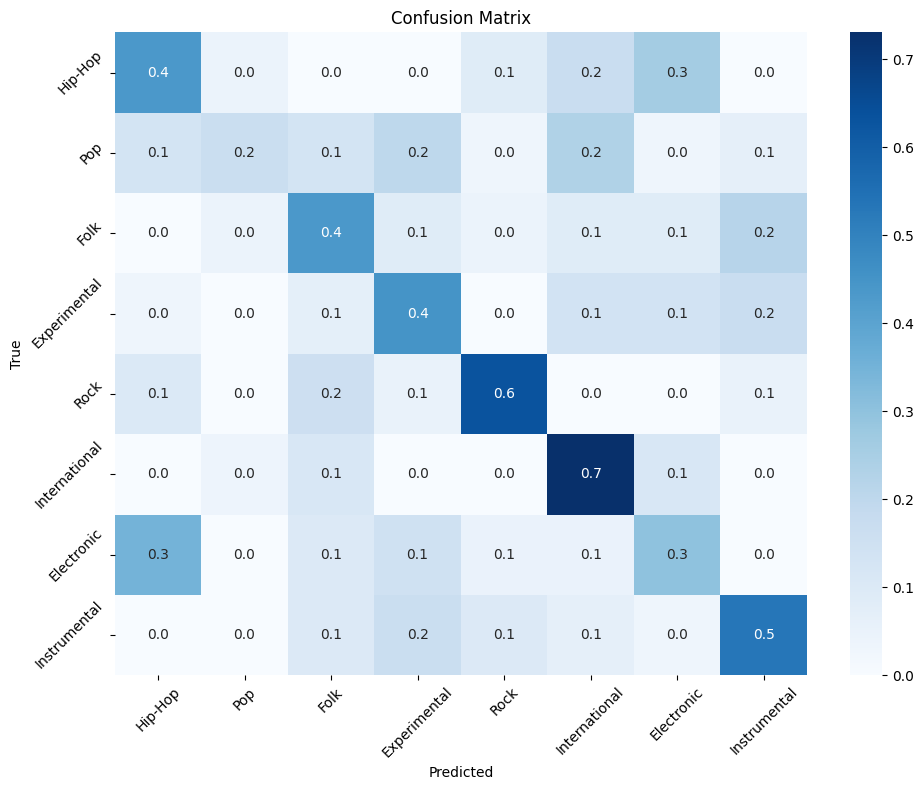

In [72]:
# Create confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_percentage, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=genre_names,
            yticklabels=genre_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()


We can see that some classes outperform others.